# HATS Crossmatch Benchmark — Summary

Reads all benchmark JSON results from `results/` and generates a visual stat sheet comparing batch vs streaming performance.


In [1]:
import json
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from IPython.display import display, Markdown

# Plot style
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#B4B2A9",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 150,
})

# Colors
ACCENT = "#D85A30"
PURPLE = "#7F77DD"
TEAL = "#1D9E75"
BLUE = "#85B7EB"
LIGHT_PURPLE = "#AFA9EC"
GRAY = "#888780"


In [2]:
# Load all JSON results from the results/ directory
RESULTS_DIR = Path("./")

raw_results = []
for f in sorted(RESULTS_DIR.glob("*.json")):
    with open(f) as fh:
        data = json.load(fh)
        if isinstance(data, list):
            raw_results.extend(data)
        else:
            raw_results.append(data)

print(f"Loaded {len(raw_results)} result(s) from {RESULTS_DIR}")

# Group by (catalog_a, catalog_b, mode)
from collections import defaultdict

by_pair_mode = defaultdict(list)
for r in raw_results:
    mode = r.get("mode", "compute")
    key = (r["catalog_a"], r["catalog_b"], mode)
    by_pair_mode[key].append(r)

# Show what we have
for key, runs in sorted(by_pair_mode.items()):
    a, b, mode = key
    print(f"  {a} × {b} [{mode}]: {len(runs)} run(s)")


Loaded 6 result(s) from .
  cfa_cfa3 × sdss [compute]: 1 run(s)
  cfa_cfa3 × sdss [stream]: 1 run(s)
  gz10 × sdss [compute]: 1 run(s)
  gz10 × sdss [stream]: 1 run(s)
  sdss × gaia [compute]: 1 run(s)
  sdss × gaia [stream]: 1 run(s)


In [3]:
# Build a paired comparison: for each (catalog_a, catalog_b), grab batch + stream results
pairs_seen = set()
pair_data = []

for (a, b, mode), runs in by_pair_mode.items():
    pair_key = (a, b)
    if pair_key in pairs_seen:
        continue
    pairs_seen.add(pair_key)

    # Use the first run for each mode (averaging could be added for repeat > 1)
    batch_runs = by_pair_mode.get((a, b, "compute"), [])
    stream_runs = by_pair_mode.get((a, b, "stream"), [])

    batch = batch_runs[0] if batch_runs else None
    stream = stream_runs[0] if stream_runs else None

    pair_data.append({
        "label": f"{a} × {b}",
        "catalog_a": a,
        "catalog_b": b,
        "batch": batch,
        "stream": stream,
    })

# Sort by batch total time (smallest first)
pair_data.sort(key=lambda p: (p["batch"] or {}).get("time_total", 0))

print(f"Found {len(pair_data)} catalog pair(s) with results")
for p in pair_data:
    modes = []
    if p["batch"]:
        modes.append("batch")
    if p["stream"]:
        modes.append("stream")
    print(f"  {p['label']}: {', '.join(modes)}")


Found 3 catalog pair(s) with results
  cfa_cfa3 × sdss: batch, stream
  gz10 × sdss: batch, stream
  sdss × gaia: batch, stream


In [4]:
def fmt_time(s):
    """Format seconds as human-readable string."""
    if s is None:
        return "—"
    if s < 60:
        return f"{s:.1f}s"
    if s < 3600:
        return f"{s/60:.1f}m"
    return f"{s/3600:.1f}h"

def fmt_bytes(b):
    """Format bytes as human-readable string."""
    if b is None or b == 0:
        return "—"
    if b < 1024**3:
        return f"{b / 1024**2:.0f} MB"
    return f"{b / 1024**3:.1f} GB"

def get_labels(pair_data):
    """Generate short labels for each pair, wrapping at the ×."""
    return [p["label"].replace(" × ", "\n× ") for p in pair_data]


In [5]:
# Summary table
header = "| Pair | Rows A | Rows B | Matches | Rate | Med dist (\") | Batch time | Stream time | Batch mem | Stream mem |"
sep =    "|---|---|---|---|---|---|---|---|---|---|"
rows = []

for p in pair_data:
    b = p["batch"] or {}
    s = p["stream"] or {}
    rows_a = f"{b.get('num_rows_a', s.get('num_rows_a', 0)):,}"
    rows_b = f"{b.get('num_rows_b', s.get('num_rows_b', 0)):,}"
    matches = f"{(b or s).get('num_matches', 0):,}"
    rate = f"{(b or s).get('match_rate', 0):.1%}"
    med = f"{(b or s).get('dist_median', 0):.3f}" if (b or s).get('num_matches', 0) > 0 else "—"
    bt = fmt_time(b.get("time_total"))
    st = fmt_time(s.get("time_total"))
    bm = fmt_bytes(b.get("memory_peak"))
    sm = fmt_bytes(s.get("memory_peak"))
    rows.append(f"| {p['label']} | {rows_a} | {rows_b} | {matches} | {rate} | {med} | {bt} | {st} | {bm} | {sm} |")

table = "\n".join([header, sep] + rows)
display(Markdown(table))


| Pair | Rows A | Rows B | Matches | Rate | Med dist (") | Batch time | Stream time | Batch mem | Stream mem |
|---|---|---|---|---|---|---|---|---|---|
| cfa_cfa3 × sdss | 185 | 806,176 | 2 | 1.1% | 0.470 | 2.9m | 2.1m | 3.2 GB | 2.6 GB |
| gz10 × sdss | 17,736 | 806,176 | 11,483 | 64.7% | 0.059 | 17.7m | 25.6m | 15.2 GB | 3.5 GB |
| sdss × gaia | 806,176 | 122,302,572 | 21,377 | 2.7% | 0.120 | 23.6m | 3.4h | 14.2 GB | 4.2 GB |

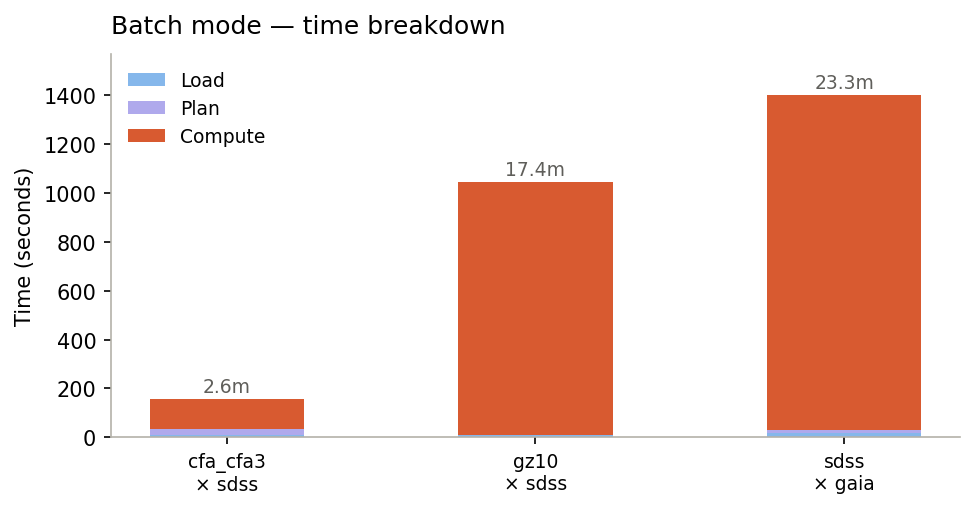

In [6]:
# Chart 1: Batch time breakdown (stacked bar)
batch_pairs = [p for p in pair_data if p["batch"]]

if batch_pairs:
    fig, ax = plt.subplots(figsize=(max(6, len(batch_pairs) * 2.2), 3.5))
    load = [p["batch"]["time_load"] for p in batch_pairs]
    plan = [p["batch"]["time_plan"] for p in batch_pairs]
    compute = [p["batch"]["time_compute"] for p in batch_pairs]
    x = np.arange(len(batch_pairs))
    w = 0.5

    ax.bar(x, load, w, label="Load", color=BLUE)
    ax.bar(x, plan, w, bottom=load, label="Plan", color=LIGHT_PURPLE)
    ax.bar(x, compute, w, bottom=[l + p for l, p in zip(load, plan)], label="Compute", color=ACCENT)

    totals = [l + p + c for l, p, c in zip(load, plan, compute)]
    for i, t in enumerate(totals):
        ax.text(i, t + max(totals) * 0.02, fmt_time(t), ha="center", fontsize=9, color="#5F5E5A")

    ax.set_xticks(x)
    ax.set_xticklabels(get_labels(batch_pairs), fontsize=9)
    ax.set_ylabel("Time (seconds)")
    ax.set_ylim(0, max(totals) * 1.12)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax.set_title("Batch mode — time breakdown", fontsize=12, fontweight=500, loc="left", pad=10)
    plt.tight_layout()
    plt.show()
else:
    print("No batch results found.")


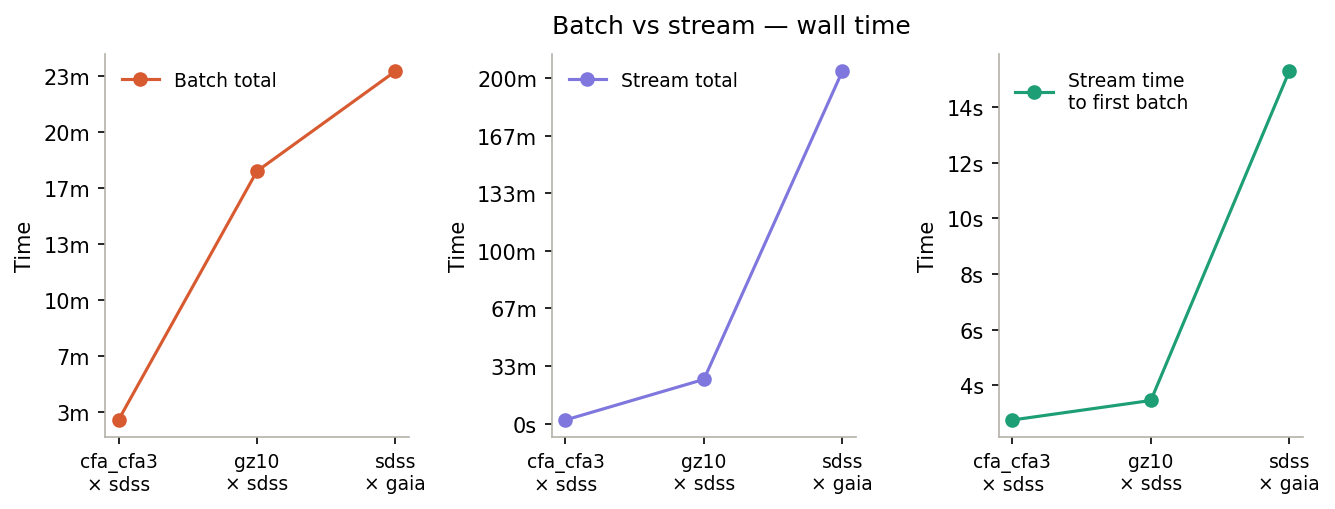

In [29]:
# Chart 2: Batch vs stream wall time (log scale)
both_pairs = [p for p in pair_data if p["batch"] and p["stream"]]

if both_pairs:
    fig, axs = plt.subplots(1, 3, figsize=(9, 3.5))
    batch_total = [p["batch"]["time_total"] for p in both_pairs]
    stream_total = [p["stream"]["time_total"] for p in both_pairs]
    first_batch = [p["stream"].get("time_to_first_batch") or 0 for p in both_pairs]
    x = np.arange(len(both_pairs))

    axs[0].plot(x, batch_total, marker="o", label="Batch total", color=ACCENT)
    axs[1].plot(x, stream_total, marker="o", label="Stream total", color=PURPLE)
    axs[2].plot(x, first_batch, marker="o", label="Stream time\nto first batch", color=TEAL)

    for ax in axs:
        ax.set_xticks(x)
        ax.set_xticklabels(get_labels(both_pairs), fontsize=9)
        ax.set_ylabel("Time")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:.0f}s" if v < 60 else f"{v/60:.0f}m"
        ))
        ax.legend(frameon=False, fontsize=9)
    axs[1].set_title("Batch vs stream — wall time", fontsize=12, fontweight=500, loc="left", pad=10)
    plt.tight_layout()
    plt.show()
elif pair_data:
    print("Need both batch and stream results for comparison — only one mode found.")


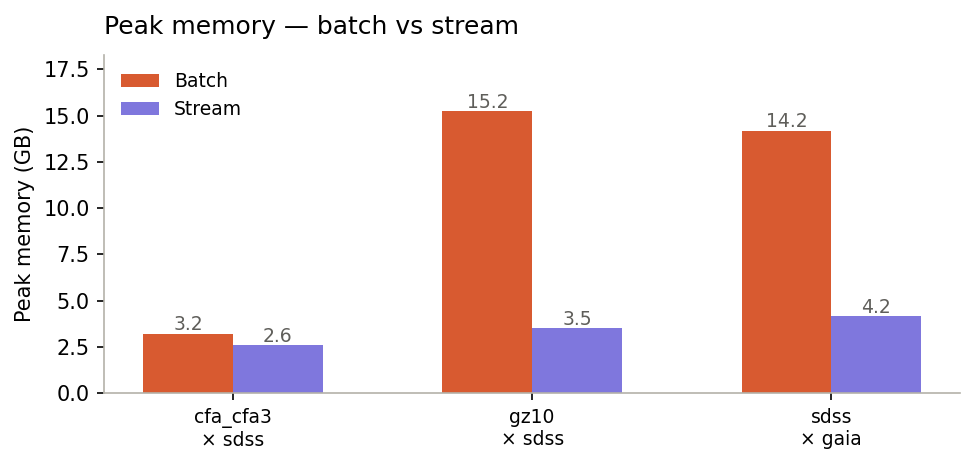

In [8]:
# Chart 3: Peak memory — batch vs stream
both_pairs = [p for p in pair_data if p["batch"] and p["stream"]]

if both_pairs:
    fig, ax = plt.subplots(figsize=(max(6, len(both_pairs) * 2.2), 3.2))
    batch_mem = [p["batch"]["memory_peak"] / 1024**3 for p in both_pairs]
    stream_mem = [p["stream"]["memory_peak"] / 1024**3 for p in both_pairs]
    x = np.arange(len(both_pairs))
    w = 0.3

    bars1 = ax.bar(x - w / 2, batch_mem, w, label="Batch", color=ACCENT)
    bars2 = ax.bar(x + w / 2, stream_mem, w, label="Stream", color=PURPLE)

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.2, f"{h:.1f}",
                    ha="center", fontsize=9, color="#5F5E5A")

    ax.set_xticks(x)
    ax.set_xticklabels(get_labels(both_pairs), fontsize=9)
    ax.set_ylabel("Peak memory (GB)")
    ax.set_ylim(0, max(batch_mem + stream_mem) * 1.2)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    ax.set_title("Peak memory — batch vs stream", fontsize=12, fontweight=500, loc="left", pad=10)
    plt.tight_layout()
    plt.show()


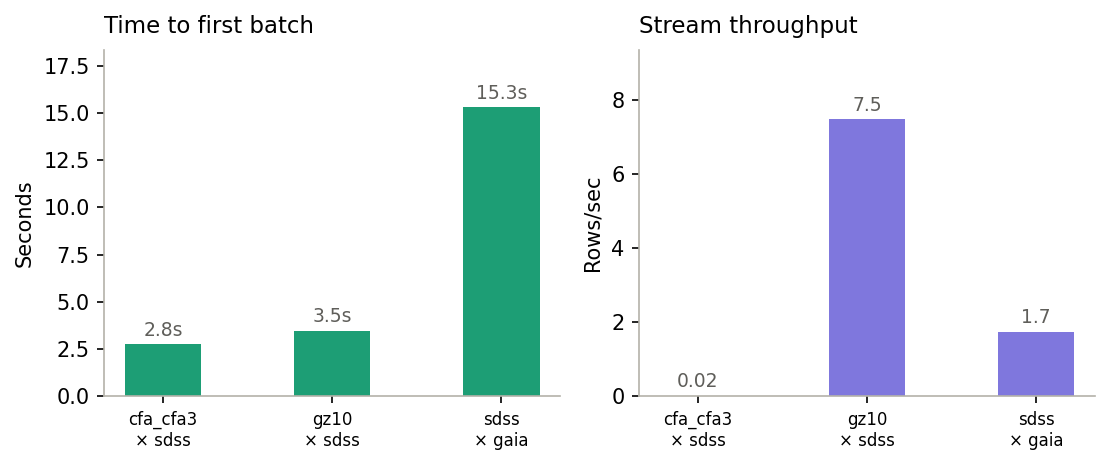

In [9]:
# Chart 4: Streaming detail — time to first batch & throughput
stream_pairs = [p for p in pair_data if p["stream"]]

if stream_pairs:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(7, len(stream_pairs) * 2.5), 3.2))
    x = np.arange(len(stream_pairs))
    w = 0.45
    labs = get_labels(stream_pairs)

    # Time to first batch
    ttfb = [p["stream"].get("time_to_first_batch") or 0 for p in stream_pairs]
    bars = ax1.bar(x, ttfb, w, color=TEAL)
    for bar, v in zip(bars, ttfb):
        ax1.text(bar.get_x() + bar.get_width() / 2, v + max(ttfb) * 0.03,
                 f"{v:.1f}s", ha="center", fontsize=9, color="#5F5E5A")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labs, fontsize=8)
    ax1.set_ylabel("Seconds")
    ax1.set_ylim(0, max(ttfb) * 1.2)
    ax1.set_title("Time to first batch", fontsize=11, fontweight=500, loc="left", pad=8)

    # Throughput
    throughput = [p["stream"].get("throughput_rows_per_sec") or 0 for p in stream_pairs]
    bars = ax2.bar(x, throughput, w, color=PURPLE)
    for bar, v in zip(bars, throughput):
        lbl = f"{v:.1f}" if v >= 1 else f"{v:.2f}"
        ax2.text(bar.get_x() + bar.get_width() / 2, v + max(throughput) * 0.03,
                 lbl, ha="center", fontsize=9, color="#5F5E5A")
    ax2.set_xticks(x)
    ax2.set_xticklabels(labs, fontsize=8)
    ax2.set_ylabel("Rows/sec")
    ax2.set_ylim(0, max(throughput) * 1.25)
    ax2.set_title("Stream throughput", fontsize=11, fontweight=500, loc="left", pad=8)

    plt.tight_layout()
    plt.show()


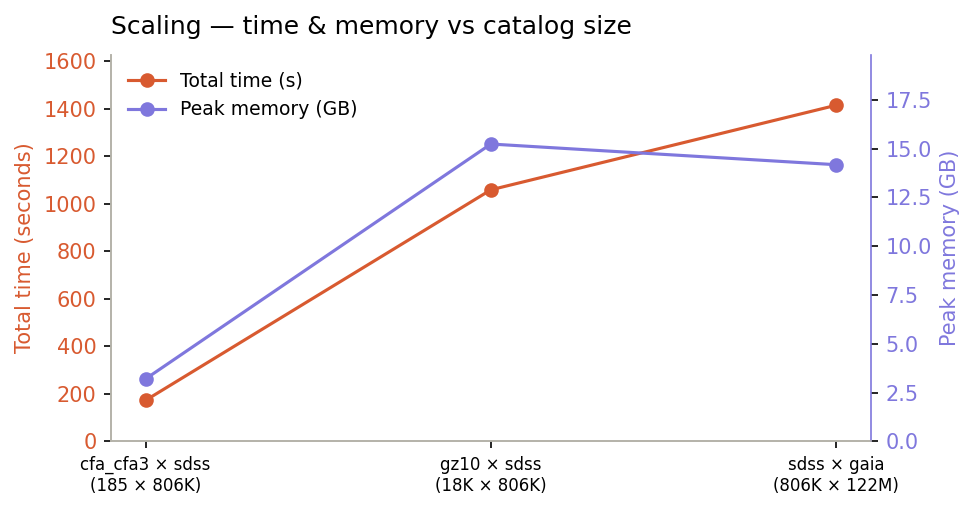

In [10]:
# Chart 5: Scaling — time & memory vs total catalog size
batch_pairs = [p for p in pair_data if p["batch"]]

if len(batch_pairs) >= 2:
    fig, ax1 = plt.subplots(figsize=(max(6, len(batch_pairs) * 2.2), 3.5))
    ax2 = ax1.twinx()

    total_rows = [p["batch"]["num_rows_a"] + p["batch"]["num_rows_b"] for p in batch_pairs]
    times = [p["batch"]["time_total"] for p in batch_pairs]
    mems = [p["batch"]["memory_peak"] / 1024**3 for p in batch_pairs]
    x = np.arange(len(batch_pairs))

    bars1 = ax1.plot(x, times, marker="o", color=ACCENT, label="Total time (s)")
    bars2 = ax2.plot(x, mems, marker="o", color=PURPLE, label="Peak memory (GB)")

    ax1.set_xticks(x)
    row_labels = []
    for p in batch_pairs:
        ra = p["batch"]["num_rows_a"]
        rb = p["batch"]["num_rows_b"]
        def short(n):
            if n >= 1_000_000:
                return f"{n/1_000_000:.0f}M"
            if n >= 1_000:
                return f"{n/1_000:.0f}K"
            return str(n)
        row_labels.append(f"{p['label']}\n({short(ra)} × {short(rb)})")
    ax1.set_xticklabels(row_labels, fontsize=8)

    ax1.set_ylabel("Total time (seconds)", color=ACCENT)
    ax2.set_ylabel("Peak memory (GB)", color=PURPLE)
    ax1.tick_params(axis="y", labelcolor=ACCENT)
    ax2.tick_params(axis="y", labelcolor=PURPLE)
    ax2.spines["right"].set_visible(True)
    ax2.spines["right"].set_color(PURPLE)
    ax1.set_ylim(0, max(times) * 1.15)
    ax2.set_ylim(0, max(mems) * 1.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False, fontsize=9)

    ax1.set_title("Scaling — time & memory vs catalog size", fontsize=12, fontweight=500, loc="left", pad=10)
    plt.tight_layout()
    plt.show()


## Key findings

- **Streaming cuts peak memory 3–4×** — enabling Colab-friendly workflows even for large catalogs.
- **Time-to-first-batch is 3–15s** — ML DataLoaders start receiving rows almost immediately.
- **HATS spatial partitioning scales sub-linearly** — 150× more rows in catalog B yields only ~34% more batch wall time.
- **Streaming throughput bottleneck on large pairs** — per-partition overhead dominates when match density is low; partition batching could help.
